<a href="https://colab.research.google.com/github/ValeriaGomez13/Diplomado/blob/Modelos-Estadisticos/Estadistica_inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimador Máximo Verosímil

Existen distintos métodos para estimar parámetros desconocidos a partit de un conjunto de datos. El estimador máximo verosímil (MLE) responde a la siguiente pregunta:

¿Para qué valor del parámetro, los datos observados tienen la probabilidad más alta?

**Ejemplo 1**

Una moneda se lanza 100 veces, dado que se obtienen 55 soles, encontrar el estimador máximo verosímil (MLE) para la probabilidad $p$ de obtener sol en un solo lanzamiento,

Podemos pensar en contar el número de soles en los 100 lanzamientos, entonces la probabilidad de obtener 55 soles en este esperimento, es la siguiente:

Si $X$: el número de soles que se obtienen al lanzar una moneda se tiene que $X \sim Bin(100,p)$, es decir,

$$ P(55\text{ soles}; p) = \binom{100}{55}p^{55}(1-p)^{100-55} $$

**Funcion de verosímilitud**

Sea $X_1,X_2,\dots,X_n$ una muestra aleatoria con $f(x;\theta)$. La función de verosímilitud (likelihood) es:
$$ f(x_1,\dots,x_n;\theta) = f(x_1;\theta)\cdots f(x_n;\theta) $$
Entonces,
$$ L(x_1,\dots,x_n;\theta) = \prod_{i=1}^n f(x_i,\theta) $$

**Propiedades**

- INVARIANZA: Si $\hat{\theta}$ es el estimador de maxima verosimilitud de $\hat{\theta}$ y si g es biyectiva, entonces $g(\theta)$ es el estimador de máxima verosimilitud de $g(\theta)$
- CONSISTENCIA: Un estimador $\hat{\theta}_n$ proveniente de la muestra $X_1,...,X_n$ se dice consistente si para cada $\epsilon > 0$ y $\theta \in \Omega$

$$ \lim_{n \rightarrow \infty} \mathbb{P}(|\hat{\theta}_n - \theta| < \epsilon) = 1 $$

Denotamos esta convergencia como:

$$ \hat{\theta}_n \to _{n \to \infty} ^{\mathbb{P}} \theta $$

**Ejemplo**

Si $X_1,\dots,X_n$ es una m.a. Poisson($\lambda$), entonces
$$ L(x_1,\dots,x_n;\lambda) = \frac{e^{n\lambda}\lambda\sum x_i}{\prod x_i!} $$



**Estimador máximo verosímil** es el valor de $\theta$, donde $(x_1,\dots,x_n;\theta)$ alcanza el máximo.

Pasos:

- $ L(x_1,\dots,x_n;\theta) = \prod_{i=1}^n f(x_i,\theta) $

- $ \ln L(x_1,\dots,x_n;\theta) $

- $ \frac{d\ln L(x_1,\dots,x_n;\theta)}{d\theta} $

- $ \frac{d\ln L(x_1,\dots,x_n;\theta)}{d\theta} = 0 $

y despejar $\theta$ para encontrar el máximo

Para nuestro caso, tenemos
$$ \frac{P(55 \text{ soles};p)}{dp} = \binom{100}{55}p^{55}(1-p)^{45} - 45p^{55}(1-p)^{44} = 0 $$
entonces, resolviendo para $p$, se tiene
$$ \binom{100}{55}p^{55}(1-p)^{45} = 45p^{55}(1-p)^{44} $$
entonces
$$ 55(1-p) = 45 p $$
entonces,
$$ p = 100/55 $$
Por lo tanto, el MLE para $p$, es $\hat{p}=0.55$

In [1]:
from scipy.stats import bernoulli, binom
import numpy as np
import sympy # para calculo simbolico y algebraico -> encontrar el estimador de manera analitica
from sympy.abc import x

In [2]:
# Definir a p como una variable simbolica positiva
p = sympy.symbols('p', positive=True)
f = p**55 * (1-p)**(100-55)
phat = sympy.solve(sympy.diff(f,p),p)[0]

print('El estimador de máxima verosimilitud es', phat)

El estimador de máxima verosimilitud es 11/20


Otro ejemplo:

In [3]:
r = binom.rvs(1,0.7, size = 100)
r

array([0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0])

In [4]:
f = p**x * (1-p)**(1-x)
J = np.prod([f.subs(x,i) for i in r])
logJ = sympy.expand_log(sympy.log(J)) #Logaritmo
phat = sympy.solve(sympy.diff(logJ, p),p)[0]

print('El estimador de máxima verosimilitud es', phat)

El estimador de máxima verosimilitud es 16/25


**Ejercicio**

El tiempo de retardo para pacientes con enfermedad coronaria potencial se define como la duración entre el comienzo de un síntoma agudo cardiovascular y la llegada a la unidad de emergencia.

Se supone que el tiempo de retardo sigue una distribución exponencial con parámetro  θ .

Se registraron los tiempos de retardo (en minutos) en la clínica para los primeros 20 pacientes:

525, 719, 2880, 150, 30, 251, 45, 858, 15, 47, 90, 56, 68, 6, 189, 180, 60, 60, 294, 747

Encuentra un estimador por el método de momentos para la media de la distribución.
Encuentra el valor del estimador con los datos dados.

La funcion de densidad de la distribucion esponencial con parametro $\theta$ es:
$$ f(x;\theta) = \theta e^{-\theta x} $$

Su media de distribucion  es:
$$ \mathbb{E}[X] = \frac{1}{\theta} $$

Ahora, tenemos que:
$$ \bar{x} = \frac{1}{n} \sum x_i $$

Entonces, utilizando el **método de momentos** tenemos que:
$$ \frac{1}{\theta} = \bar{x} $$

Como queremos obtener el valor de $\theta$ lo despejamos, obteniendo
$$ \theta = \frac{1}{\bar{x}} $$

In [5]:
# DATOS
tiempo = [525, 719, 2880, 150, 30, 251, 45, 858, 15, 47, 90, 56, 68, 6, 189, 180, 60, 60, 294, 747]
#Obtenemos la media muestral
media_muestral = np.mean(tiempo)

#Obtenemos el valor de theta, que es 1 entre la media muestral
theta = 1/media_muestral

print('El estimador por el método de momentos es', theta)

El estimador por el método de momentos es 0.002751031636863824


**Ejercicio**

Sea una muestra aleatoria $X_1, \ldots, X_n \overset{iid}{\sim} \mathcal{N}(\mu, \sigma^2) $.
Queremos encontrar el estimador de máxima verosimilitud para $\mu$ y $\sigma^2$.

La función de densidad es:
$$ f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right) \cdot \mathbf{1}_{(-\infty, \infty)}(x)$$

In [ ]:
mu, sigma = sympy.symbols('mu sigma')
# Generamos una muestra de datos
muestra = np.random.normal(loc=5, scale=2, size=100)  # media 5, desviación estándar 2 y tamaño de muestra 100
f = (1 / (sympy.sqrt(2 * sympy.pi * (sigma**2)))) * sympy.exp(-((x - mu)**2) / (2 * sigma**2))
J = np.prod([f.subs(x,i) for i in muestra])
logJ = sympy.expand_log(sympy.log(J))
mu_hat = sympy.solve(sympy.diff(logJ, mu),mu)[0]
sigma_hat = sympy.solve(sympy.diff(logJ, sigma),sigma)[0]

print('El estimador de máxima verosimilitud para mu es', mu_hat)
print('El estimador de máxima verosimilitud para sigma^2 es', sigma_hat)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-6-a2bf9cb0e6ae>", line 7, in <cell line: 0>
    mu_hat = sympy.solve(sympy.diff(logJ, mu),mu)[0]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sympy/solvers/solvers.py", line 1121, in solve
    f[i] = nsimplify(fi, rational=True)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sympy/simplify/simplify.py", line 1446, in nsimplify
    return _real_to_rational(expr, tolerance, rational_conversion)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sympy/simplify/simplify.py", line 1582, in _real_to_rational
    return p.subs(reps, simultaneous=True)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3

**Ejercicio**

Suponga que la vida util de los focos de cierta marca, se modela mediante una distribución exponencial de parametro $\theta$ (desconocido). Probamos 5 focos y encontramos que tienen una vida útil de $2,3,1,3$ y $5$ años, respectivamente. ¿Cuál es el MLE para $\theta$?

In [6]:
theta = sympy.Symbol('theta')
# Datos vida útil foco
vida_util = [2, 3, 1, 3, 5]

f = (1/theta) * sympy.exp(-x/theta)
J = sympy.prod([f.subs(x, i) for i in vida_util])
logJ = sympy.expand_log(sympy.log(J))
theta_hat = sympy.solve(sympy.diff(logJ, theta), theta)[0]

print('El estimador de máxima verosimilitud para theta es', theta_hat)

El estimador de máxima verosimilitud para theta es 14/5


**Ejercio.**

Sea $(x_1,\ldots,x_n)$ una m.a
$$ f(x;\theta) = \theta(1+x)^{-(1+x)} \cdot \mathbf{1}_{\{0, \infty\}}(x), \quad \theta > 0 $$
Estimar $\theta$ por momentos asumiendo que $\theta > 1$


El primer momento de la distribucion se puede calcular como:
$$ \mathbb{E} = \int_{0}^{\infty} x f(x;\theta) dx $$

Para la distribucion dada, la media se relaciona con $\theta$ de la siguiente manera:
$$ \mathbb{E}[X] = \frac{1}{\theta - 1} $$

Ahora, igualamos la media muestral con la media teorica
$$ \bar{x} = \frac{1}{\theta - 1} $$

Despejando $\theta$ obetenemos
$$ \hat{\theta} = 1 + \frac{1}{\bar{x}} $$

In [7]:
# Ejemplo
datos = [2, 3, 4, 5, 6]

# Calculamos la media muestral
media_muestra = np.mean(datos)

# Calculamos el estimador de máxima verosimilitud
theta_hat = 1 + (1/media_muestra)

print('El estimador de máxima verosimilitud es', theta_hat)

El estimador de máxima verosimilitud es 1.25


#Intervalos de confianza

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

## Intervalo de Confianza para la media $\mu$ de una distribución normal ($\sigma$ conocida)

Sea $X_1, \dots, X_n$ una m.a. $X_i \sim \mathcal{N}(\mu, \sigma^2)$. Entonces:

- $\bar{X} \sim \mathcal{N}(\mu, \frac{\sigma^2}{n})$
- $Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0,1)$

### Nivel de significancia (error): $\alpha$

El intervalo de confianza se basa en que:
$$
\mathbb{P}\left( -z_{\alpha/2} < \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} < z_{\alpha/2} \right)
= \mathbb{P}\left( \bar{X} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}} < \mu < \bar{X} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right)
= 1 - \alpha
$$

### El intervalo del $(1 - \alpha) \cdot 100\%$ de confianza para $\mu$ (con $\sigma$ conocida) es:

$$
\left( \bar{X} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}}, \quad \bar{X} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right)
$$
donde

- $\sigma$ = desviación estándar  
- $\frac{\sigma}{\sqrt{n}}$ = error estándar de la media  
- $z_{\alpha/2}$ determina el nivel de confianza  
- El intervalo está centrado en $\bar{X}$

**Observación**

- A mayor $n$, menor es el error estándar, y el intervalo de confianza es más pequeño.
- Esto hace que se acerque más a la media $\mu$, es decir, que haya menor variación.

**Ejemplo**

Para taratar de estimar la media del consumo por cliente en un gran restaurante, se reunieron datos de una muestra de 49 clientes durante 3 semanas

**a)** Supongams que la **desviacion estándar de la población** es de $\$2.50$. ¿Cuál es el error estandar de la media

**b)** Con un nivel dde confianza de $95\%$, ¿cuál es el margen de error?

**c)** Si la **media de la muestra** es de $\$22.60$, ¿cuál es el intervalo de confianza del $95\%$ para la media de la población?

In [9]:
# Datos
n = 49
sigma = 2.50
media_muestral = 22.60
confianza = 0.95

# a) Error estándar de la media
error_estandar = sigma / np.sqrt(n)
print(f' a) Error estándar de la media: {error_estandar: .2f}')

# b) Margen de error
z = st.norm.ppf(1-(1-confianza) / 2)
margen_error = z * error_estandar
print(f' b) Margen de error con 95% de confianza: {margen_error:.2f}')

# c)
Limite_inferior = media_muestral - margen_error
Limite_superior = media_muestral + margen_error
print(f' c) Intervalo de confianza del 95%: ({Limite_inferior:.2f}, {Limite_superior:.2f})')

 a) Error estándar de la media:  0.36
 b) Margen de error con 95% de confianza: 0.70
 c) Intervalo de confianza del 95%: (21.90, 23.30)


$ 1-\alpha = 0.95 $, implica que $z_{\alpha / 2} = z_{0.025} = 1.96 $

**Ejemplo**

Supongamos que se toma una muestra aleatoria de 100 personas para estimar la media del peso de una población, y se obtiene que la media muetsral es de $70$ kg con una desviación estándar que es conocida de $10$ kg. Para un nuvel de confianza del $95\%$, calcular el intervalo de confianza

In [10]:
# Datos
n = 100
media_muestral = 70
desviacion_estandar = 10
nivel_confianza = 0.95

error_estandar = desviacion_estandar / np.sqrt(n)

# Utilizaremos la funcion scipy.stats.norm.interval
# Sintaxis
# scipy.stats.norm.interval(confidence, loc = media, scale = error_estandar )

intervalo = st.norm.interval(confidence = nivel_confianza, loc = media_muestral, scale = error_estandar)
print(f'El intervalo de confianza del 95% es: {intervalo}')

El intervalo de confianza del 95% es: (np.float64(68.04003601545995), np.float64(71.95996398454005))


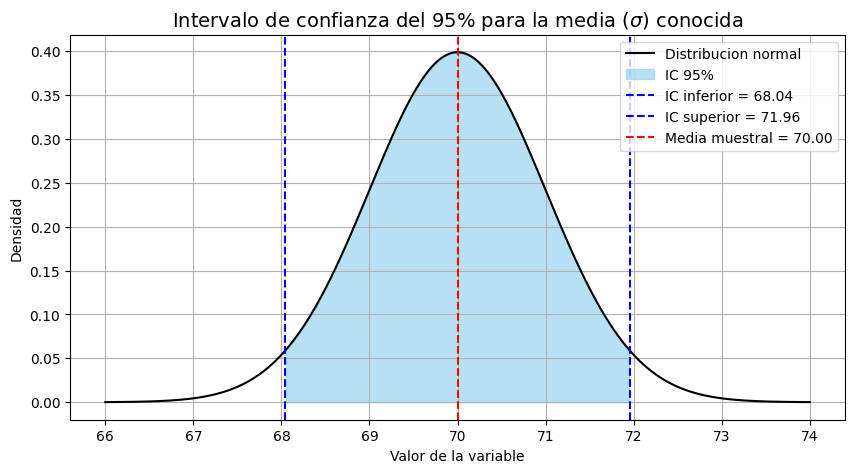

In [11]:
# Puntos para graficar la curva normal
x = np.linspace(media_muestral - 4*error_estandar, media_muestral + 4*error_estandar, 500)
y = st.norm.pdf(x, loc = media_muestral, scale = error_estandar)

# Grafica
plt.figure(figsize = (10,5))
plt.plot(x, y, label = 'Distribucion normal', color = 'black')

# Sombrear el intervalo de confianza
plt.fill_between(x, y, where = (x >= intervalo[0]) & (x <= intervalo[1]), color = 'skyblue', alpha = 0.6, label = 'IC 95%')

# Lineas verticales
plt.axvline(intervalo[0], color = 'blue', linestyle = '--', label = f'IC inferior = {intervalo[0]:.2f}')
plt.axvline(intervalo[1], color = 'blue', linestyle = '--', label = f'IC superior = {intervalo[1]:.2f}')
plt.axvline(media_muestral, color = 'red', linestyle = '--', label = f'Media muestral = {media_muestral:.2f}')

# Estetica
plt.title('Intervalo de confianza del 95% para la media ($\\sigma$) conocida', fontsize = 14)
plt.xlabel('Valor de la variable')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

## Intervalo de Confianza para la media $\mu$ de una distribución normal ($\sigma$ desconocida)

Sea $X_1, \dots, X_n$ una m.a. $X_i \sim \mathcal{N}(\mu, \sigma^2)$. Entonces:

- $\bar{X} \sim \mathcal{N}(\mu, \frac{\sigma^2}{n})$
- $Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0,1)$

Si el tamaño de la muestra es menor a $30$, se utiliza la $t$

### Estadístico $t$

Definimos el estadístico $t$ de la siguiente manera:
$$ T = \frac{\bar{x}-\mu}{s/\sqrt{n}} \sim t_{n-1} $$

### El intervalo del $(1 - \alpha) \cdot 100\%$ de confianza para $\mu$ (con $\sigma$ deconocida) es:

$$
\left( \bar{X} - t_{\alpha/2} \frac{s}{\sqrt{n}}, \quad \bar{X} + t_{\alpha/2} \frac{s}{\sqrt{n}} \right)
$$
donde

- $s$ = desviación estándar muestral  
- $\frac{s}{\sqrt{n}}$ = error estándar de la media  
- $t_{\alpha/2}$ determina el nivel de confianza  
- El intervalo está centrado en $\bar{X}$

**Ejemplo**

Supongamos que tenemos los siguientes datos
$$ datos = [45, 55, 67, 45, 68, 79, 98, 87, 84, 82] $$
Calcular un intervalo de confianza para la media.

In [12]:
# Datos
data = [45, 55, 67, 45, 68, 79, 98, 87, 84, 82]
confidence = 0.95
gl = len(data) - 1 # grados de libertad

# Media y error estandar
mean = np.mean(data)
error_est = st.sem(data)

# Intervalo de confianza usando t de Student
intervalo = st.t.interval(confidence, gl, loc = mean, scale = error_est)

print(f'La media muetsral es: {mean: .2f}')
print(f'El error estandar es: {error_est: .2f}')
print(f'El intervalo de confianza del 95% es: {intervalo}')

La media muetsral es:  71.00
El error estandar es:  5.75
El intervalo de confianza del 95% es: (np.float64(58.000521742293884), np.float64(83.99947825770612))


**Ejemplo**

Los articulos de céramica utilizados sobre velas electricas sobrecargadas se rompen con diferentes presiones. Supongamos que los datos provienen de una distribución normal.

La resistencia a la ruptura fue medida en una muestra de 100 articulos, y el promedio fue de $1750$ con una desviación estándar de $315.80$.

**a)** Estimar con un nivel de confianza del $90\%$ a la media poblacionalde la presión de la ruptura.

**b)** Estiamar con un nivel de confianza del $90\%$ a la varianza poblacional

In [13]:
from scipy.stats import chi2

In [14]:
# Datos
n = 100
media_muestral = 1750
desv_estandar_muestral = 315.8
confianza = 0.90

# a) Usar la normal ya que el tamaño de la muesta es grande
error_est = desv_estandar_muestral / np.sqrt(n)
intervalo_media = st.norm.interval(confidence = confianza, loc = media_muestral, scale = error_est)
print(f'El intervalo de confianza del 90% de la media es: {intervalo_media}')

# b) Intervalo de confianza para la varianza (Usar chi-cuadrada)
alpha = 1-confianza
gl = n-1
s2 = desv_estandar_muestral**2

# Cuantiles de la chi_cuadrada
chi2_inf = st.chi2.ppf(alpha/2, df = gl)
chi2_sup = st.chi2.ppf(1-alpha/2, df = gl)

# Intervalo de confianza
intervalo_varianza = ((gl * s2) / chi2_sup, (gl * s2) / chi2_inf)
print(f'El intervalo de confianza del 90% de la varianza es: {intervalo_varianza}')

# Otra forma
chi2_low, chi2_high = chi2.interval(confidence = confianza, df = gl)
intervalo_varianza1 = ((gl * s2) / chi2_high, (gl * s2) / chi2_low)
print(f'El intervalo de confianza del 90% de la varianza es: {intervalo_varianza1}')

El intervalo de confianza del 90% de la media es: (np.float64(1698.0555224608725), np.float64(1801.9444775391275))
El intervalo de confianza del 90% de la varianza es: (np.float64(80123.48643850331), np.float64(128146.71537457063))
El intervalo de confianza del 90% de la varianza es: (np.float64(80123.48643850331), np.float64(128146.71537457063))


**Ejemplo**

El artículo "*Evaluation of a Ventilation Strategy to Prevent Barotrauma in Patients at High Risk for Acute Respiratory Distress Syndome*" reportó sobre un experimento con 120 pacientes con anestesistas con cuidados intensivos (UCI), los cuales fueron divididos al azar en dos grupos, donde cada uno esta compuesto por 60 pacientes.

- GRUPO A: promedio de permanencia = $14.1$ horas
- GRUPO B: promedio de permanencia = $17.5$ horas
- Desviación estándar en ambos casos = $5.1$ horas

Encontrar un intervalo del $95\%$ de confianza para la diferencia de medias pobracionales ($\mu_A - \mu_B $)

In [15]:
# Datos
n1 = 60
n2 = 60
media1 = 14.1
media2 = 17.5
sigma = 5.1
confianza = 0.95
alpha = 1-confianza
gl = n1 + n2 - 2

# Valor critico
z = st.norm.ppf(1-(1-confianza)/2)

# Error estándar
error_est = sigma * np.sqrt(1/n1 + 1/n2)
dif_medias = media1 - media2
margen_error = z * error_est

lim_inf = dif_medias - margen_error
lim_sup = dif_medias + margen_error

print(f'Diferencia de las medias: ({dif_medias:.2f})')
print(f'El intervalo de confianza del 95% es: ({lim_inf:.2f}, {lim_sup:.2f})')

Diferencia de las medias: (-3.40)
El intervalo de confianza del 95% es: (-5.22, -1.58)


**Ejercicio**

En una encuesta de una Universidad, 225 estudiantes son seleccionados al azar de los que toman cálculo y se les pregunta si cálculo es su materia favorita. 100 estudiantes responden que el cálculo es su materia favorita. Proporcione un intervalo de confianza del 95 %  para la proporción de todos los estudiantes que toman cálculo y que la consideran su materia favorita.  

In [23]:
# Datos
n = 225
x = 100
p_hat = x / n
nivel_confianza = 0.95

error_estandar = np.sqrt(p_hat * (1 - p_hat) / n)

z = st.norm.ppf(1 - (1 - nivel_confianza) / 2)

intervalo_prop = st.norm.interval(confidence=nivel_confianza, loc=p_hat, scale=error_estandar)

print(f"Intervalo de confianza del 95% para la proporción: ({intervalo_prop[0]:.3f}, {intervalo_prop[1]:.3f})")

Intervalo de confianza del 95% para la proporción: (0.380, 0.509)


**Ejercicio**

Los datos $1.2,\ 2.1,\ 2.3,\ 1.9,\ 3.0,\ 1.5,\ 2.8,\ 2.4,\ 1.7,\ 2.6,\ 2.0,\ 1.8,\ 3.1,\ 2.2,\ 2.5$ se toman a partir de una distribución normal $N(\mu,\sigma^2)$ con $\mu$ desconocida.

**a)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\mu$, dado que $\sigma =2$.

**b)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\mu$.

**c)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\sigma^2$.

In [25]:
datos = np.array([1.2, 2.1, 2.3, 1.9, 3.0, 1.5, 2.8, 2.4, 1.7, 2.6, 2.0, 1.8, 3.1, 2.2, 2.5])
n = len(datos)
confianza = 0.90
media = np.mean(datos)
varianza = np.var(datos, ddof=1)
desv_std = np.std(datos, ddof=1)

# a) IC para mu con sigma conocida (=2)
sigma = 2
error_estandar_a = sigma / np.sqrt(n)
z = st.norm.ppf(1 - (1 - confianza) / 2)
lim_a = st.norm.interval(confianza, loc=media, scale=error_estandar_a)

# b) IC para mu con sigma desconocida
error_estandar_b = desv_std / np.sqrt(n)
t = st.t.ppf(1 - (1 - confianza) / 2, df=n-1)
lim_b = (media - t * error_estandar_b, media + t * error_estandar_b)

# c) IC para varianza (sigma^2)
chi2_inf = st.chi2.ppf((1 - confianza) / 2, df=n-1)
chi2_sup = st.chi2.ppf(1 - (1 - confianza) / 2, df=n-1)
lim_c = ((n - 1) * varianza / chi2_sup, (n - 1) * varianza / chi2_inf)

print("Datos muestrales: ")
print(f"media = {media:.3f}")
print(f"varianza = {varianza:.3f}")
print(f"Desviacion estandar = {desv_std:.3f}")

print("a) Intervalo de confianza del 90% para μ, con σ = 2 conocida:")
print(f"({lim_a[0]:.3f}, {lim_a[1]:.3f})")

print("b) Intervalo de confianza del 90% para μ, con σ desconocida:")
print(f"({lim_b[0]:.3f}, {lim_b[1]:.3f})")

print("c) Intervalo de confianza del 90% para σ^2:")
print(f"({lim_c[0]:.3f}, {lim_c[1]:.3f})")

Datos muestrales: 
media = 2.207
varianza = 0.296
Desviacion estandar = 0.544
a) Intervalo de confianza del 90% para μ, con σ = 2 conocida:
(1.357, 3.056)
b) Intervalo de confianza del 90% para μ, con σ desconocida:
(1.959, 2.454)
c) Intervalo de confianza del 90% para σ^2:
(0.175, 0.631)


**Ejercicio**

Los ingresos semanales promedio de las personas que trabajan en varias industrias aparecieron en el *The New York Times 1988 Almanac*.  
Esos ingresos para quienes trabajan en los servicios fueron de $\$369$. Suponga que este resultado se basó en una muestra de 250 personas dedicadas a los servicios y que la desviación estándar de la muestra fue de $\$50$. Calcula el intervalo de confianza del 95% para la media de la población de ingresos semanales de personas que trabajan en los servicios.

In [26]:
n = 250
media = 369
s = 50
confianza = 0.95

error_estandar = s / np.sqrt(n)

t = st.t.ppf(1 - (1 - confianza) / 2, df=n-1)

limite_inferior = media - t * error_estandar
limite_superior = media + t * error_estandar

print(f"Intervalo de confianza del 95% para la media de ingresos semanales: ({limite_inferior:.3f}, {limite_superior:.3f})")

Intervalo de confianza del 95% para la media de ingresos semanales: (362.772, 375.228)


**Ejercicio** En un estudio de préstamos a estudiantes, el Departamento de Educación informó que los beneficiarios del fondo Stafford Loan deberían un promedio de \$12,658 al recibirse (*USA Today*, 5 de abril de 1995). Suponga que este promedio de deuda se basa en una muestra de 480 préstamos a estudiantes y que la desviación estándar de la población de las deudas al recibirse es \$2,000.

**a)** Determina un estimado de confianza del **90%** del promedio poblacional de la deuda.

**b)** Determina un estimado de confianza del **95%** del promedio poblacional de la deuda.

**c)** Determina un estimado de confianza del **99%** del promedio poblacional de la deuda.

**d)** Describe lo que sucede con el **ancho del intervalo de confianza** a medida que se **aumenta el nivel de confianza**. ¿Parece razonable? Explica tu respuesta.

In [29]:
media = 12658
n = 480
sigma = 2000
niveles_confianza = [0.90, 0.95, 0.99]
intervalos = {}

for nivel in niveles_confianza:
    z = st.norm.ppf(1 - (1 - nivel) / 2)
    error_estandar = sigma / np.sqrt(n)
    lim_inf = media - z * error_estandar
    lim_sup = media + z * error_estandar
    ancho = lim_sup - lim_inf
    intervalos[nivel] = (lim_inf, lim_sup, ancho)

# Resultados
print(f"a) ({intervalos[0.90][0]:.2f}, {intervalos[0.90][1]:.2f} ancho = {intervalos[0.90][2]:.2f}")

print(f"b) ({intervalos[0.95][0]:.2f}, {intervalos[0.95][1]:.2f}) ancho = {intervalos[0.95][2]:.2f}")

print(f"c) ({intervalos[0.99][0]:.2f}, {intervalos[0.99][1]:.2f}) ancho = {intervalos[0.99][2]:.2f}")

a) (12507.85, 12808.15 ancho = 300.31
b) (12479.08, 12836.92) ancho = 357.84
c) (12422.86, 12893.14) ancho = 470.28


d) A medida que el nivel de confianza aumenta, el ancho del intervalo también se incrementa:
- 90% → ancho ≈ 300.31
- 95% → ancho ≈ 357.84
- 99% → ancho ≈ 470.28
Esto es razonable, ya que para estar más seguros de que el verdadero valor poblacional esté dentro del intervalo, se necesita cubrir un rango más amplio de posibles valores.

**Ejercicio**

La encuesta anual de calidad de automóviles, efectuada por *J. D. Power & Associates*, determinó que la cantidad promedio de defectos, en todas las marcas, por cada vehículo nuevo es **1.07**  (*The Wall Street Journal*, 27 de enero de 1994). Suponga que se toma una muestra de **30 automóviles nuevos** de determinada marca y se obtienen las siguientes cantidades de defectos por vehículo:
$$ 0, 1, 1, 2, 1, 0, 2, 3, 2, 1, 0, 2, 0, 0, 2, 3, 0, 4, 3, 1, 1, 1, 0, 2, 0, 2, 0, 3, 1, 0 $$

**a)** ¿Cuál es el promedio muestral de la cantidad de defectos por vehículo?

**b)** ¿Cuál es la desviación estándar de la muestra?

**c)** Determine un intervalo de confianza del 95% para la **media de defectos** por vehículo de esta marca.

**d)** Un analista sugirió que se debería **revisar una muestra mayor** antes de comparar con el promedio general de J.D. Power (1.07). ¿Respalda usted esta idea? ¿Por qué?

In [30]:
datos = np.array([0, 1, 1, 2, 1, 0, 2, 3, 2, 1, 0, 2, 0, 0, 2, 3, 0, 4, 3, 1, 1, 1, 0, 2, 0, 2, 0, 3, 1, 0])
n = len(datos)
confianza = 0.95
media = np.mean(datos)
s = np.std(datos, ddof=1)

error_estandar = s / np.sqrt(n)
t = st.t.ppf(1 - (1 - confianza) / 2, df=n-1)
lim_inf = media - t * error_estandar
lim_sup = media + t * error_estandar

print(f"a) Promedio muestral de defectos: {media:.3f}")

print(f"b) Desviación estándar muestral: {s:.3f}")

print(f"c) Intervalo de confianza del 95% para la media: ({lim_inf:.3f}, {lim_sup:.3f})")

a) Promedio muestral de defectos: 1.267
b) Desviación estándar muestral: 1.172
c) Intervalo de confianza del 95% para la media: (0.829, 1.704)


d) ¿Es razonable tomar una muestra mayor antes de comparar con el promedio general (1.07)?"

Sí, es razonable. Aunque el promedio muestral es $1.27$, el intervalo de confianza del $95%$ es $(0.83, 1.70)$, lo cual incluye el promedio general de $1.07$. Esto significa que no hay evidencia estadística suficiente para afirmar que esta marca difiere del promedio general. Una muestra más grande reduciría la variabilidad y haría más precisa la estimación.

**Ejercicio**

Un artículo que apareció en el ejemplar de noviembre de 1983 de *Consumer Reports* comparó varios tipos de baterías.  
Se informó que los siguientes datos provienen de una muestra de 20 baterías (en horas de duración):
$$ [2200, 2290, 2390, 2410, 2480, 2500, 2580, 2700, 2030, 2100, 2190, 1600, 1740, 1900, 1930, 2000, 1510, 1470, 1770, 1710] $$
Determine la media muestral, la desviación estándar muestral, y el intervalo de confianza del **90%** para la media poblacional.

In [31]:
baterias = np.array([2200, 2290, 2390, 2410, 2480, 2500, 2580, 2700, 2030, 2100,
                     2190, 1600, 1740, 1900, 1930, 2000, 1510, 1470, 1770, 1710])
n = len(baterias)
confianza = 0.90
media = np.mean(baterias)
s = np.std(baterias, ddof=1)

error_estandar = s / np.sqrt(n)
t = st.t.ppf(1 - (1 - confianza) / 2, df=n-1)
lim_inf = media - t * error_estandar
lim_sup = media + t * error_estandar

print(f"Media y desviación estándar muestral: {media:.2f} , {s:.2f}")

print(f"Intervalo de confianza del 90% para la media poblacional: ({lim_inf:.2f}, {lim_sup:.2f})")

Media y desviación estándar muestral: 2075.00 , 368.93
Intervalo de confianza del 90% para la media poblacional: (1932.35, 2217.65)


**Ejercicio**

El toxafen es un insecticida que ha sido identificado como contaminante en el ecosistema de los Grandes Lagos.  
Para investigar el efecto de la exposición al toxafen en animales, a grupos de ratas se les administró toxafen en su dieta.

El artículo *"Reproduction Study of Toxaphene in Rat"* reporta **aumentos de peso (en gramos)** de ratas a las que se les administró una **dosis baja (4 ppm)** y de ratas de **control** cuya dieta no incluía el insecticida.

- En el grupo **control**, una muestra de **23 ratas hembras** tuvo una media de **$\bar{X_2} = 210$ g** y una desviación estándar de **32 g**.
- En el grupo con **dosis baja**, una muestra de **20 ratas hembras** tuvo una media de **$\bar{X_1} = 190$ g** y una desviación estándar de **54 g**.

Encuentra un **intervalo de confianza del 90% para la diferencia de medias** poblacionales:  $\mu_1 - \mu_2$, donde:

- $\mu_1$ es la media poblacional de incremento de peso en el grupo con **dosis baja**.
- $\mu_2$ es la media poblacional de incremento de peso en el grupo **control**.

¿Sugiere este intervalo que el toxafen **reduce** el incremento de peso en ratas?  
¿Incluye el intervalo el valor 0? ¿Por qué es importante?

In [32]:
# Grupo con dosis baja
n1, x1_bar, s1 = 20, 190, 54
# Grupo control
n2, x2_bar, s2 = 23, 210, 32

confianza = 0.90

diferencia = x1_bar - x2_bar

se = np.sqrt((s1**2 / n1) + (s2**2 / n2))

df = ((s1**2 / n1 + s2**2 / n2) ** 2) / (
    ((s1**2 / n1) ** 2) / (n1 - 1) + ((s2**2 / n2) ** 2) / (n2 - 1)
)

t = st.t.ppf(1 - (1 - confianza) / 2, df=df)

lim_inf = diferencia - t * se
lim_sup = diferencia + t * se

print(f"Intervalo de confianza del 90% para μ_1 - μ_2: ({lim_inf:.2f}, {lim_sup:.2f})")


Intervalo de confianza del 90% para μ_1 - μ_2: (-43.42, 3.42)


¿El intervalo sugiere que el toxafen reduce el incremento de peso?
El intervalo incluye el 0, lo que indica que no hay evidencia suficiente para afirmar que el toxafen reduce el incremento de peso en ratas. Es posible que la diferencia observada se deba al azar.

# Pruebas de hipótesis

## Contraste de la media de una población normal con varianza conocida
### Contraste bilateral

- Hipótesis nula $H_0: \mu = \mu_0$
- Hipótesis alternativa $H_a: \mu \neq \mu_0$

Se acepta $H_0$ si el estádistico
$$ |z| = \frac{|\bar{x} - \mu_0|}{\sigma / \sqrt{n}} \leq z_{\alpha/2} $$

Se rechaza $H_0$ si el estádistico
$$ |z| = \frac{|\bar{x} - \mu_0|}{\sigma / \sqrt{n}} > z_{\alpha/2} $$

$$R_{rechazo} = \{|\bar{x} - \mu_0| > z_{\alpha/2}\frac{\sigma}{\sqrt{n}}\}$$

### Contraste unilateral

- Hipótesis nula $H_0 : \mu \leq \mu_0$
- Hipótesis alternativa $H_a : \mu > \mu_0$

Se acepta $H_0$ si el estadístico
$$ z = \frac{\bar{x}-\mu_0}{\sigma/\sqrt{n}} \leq z_\alpha $$

Se rechaza $H_0$ si el estadístico
$$ z = \frac{\bar{x}-\mu_0}{\sigma/\sqrt{n}} > z_\alpha $$

$$ R_{rechazo} = \{|\bar{x} - \mu_0| > z_{\alpha}\frac{\sigma}{\sqrt{n}}\} $$

## Contraste de la media de una población normal con varianza desconocida
### Contraste bilateral
#### Muestras grandes $n > 30$
- Hipótesis nula $H_0 : \mu = \mu_0$
- Hipótesis alternativa $H_a: \mu \neq \mu_0$

Se acepta $H_0$ si el estádistico
$$ |z| = \frac{|\bar{x} - \mu_0|}{s / \sqrt{n}} \leq z_{\alpha/2} $$

Se rechaza $H_0$ si el estádistico
$$ |z| = \frac{|\bar{x} - \mu_0|}{s / \sqrt{n}} > z_{\alpha/2} $$

$$R_{rechazo} = \{|\bar{x} - \mu_0| > z_{\alpha/2}\frac{s}{\sqrt{n}}\}$$

#### Muestras pequeñas $n \leq 30$
- Hipótesis nula $H_0 : \mu = \mu_0$
- Hipótesis alternativa $H_a: \mu \neq \mu_0$

Se acepta $H_0$ si el estádistico
$$ t = \frac{|\bar{x} - \mu_0|}{s / \sqrt{n}} \leq t_{\alpha/2}; (n-1) $$

Se rechaza $H_0$ si el estádistico
$$ |z| = \frac{|\bar{x} - \mu_0|}{s / \sqrt{n}} > t_{\alpha/2}; (n-1) $$

$$R_{rechazo} = \{|\bar{x} - \mu_0| > t_{\alpha/2}(n-1)\frac{s}{\sqrt{n}}\}$$

### Contraste unilateral
#### Muestras grandes $n > 30$

- Hipótesis nula $H_0 : \mu \leq \mu_0$
- Hipótesis alternativa $H_a : \mu > \mu_0$

Se acepta $H_0$ si el estadístico
$$ z = \frac{\bar{x}-\mu_0}{s/\sqrt{n}} \leq z_\alpha $$

Se rechaza $H_0$ si el estadístico
$$ z = \frac{\bar{x}-\mu_0}{s/\sqrt{n}} > z_\alpha $$

$$ R_{rechazo} = \{\bar{x} - \mu_0 > z_{\alpha}\frac{s}{\sqrt{n}}\} $$

#### Muestras pequeñas $n \leq 30$

- Hipótesis nula $H_0 : \mu \leq \mu_0$
- Hipótesis alternativa $H_a : \mu > \mu_0$

Se acepta $H_0$ si el estádistico
$$ t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}} \leq t_{\alpha}; (n-1) $$

Se rechaza $H_0$ si el estádistico
$$ |z| = \frac{\bar{x} - \mu_0}{s / \sqrt{n}} > t_{\alpha}; (n-1) $$

$$R_{rechazo} = \{\bar{x} - \mu_0 > t_{\alpha}(n-1)\frac{s}{\sqrt{n}}\}$$




## Contraste de igualdad de medias de dos poblaciones normales de varianzas desconocidad
### Contraste bilateral
- Hipótesis nula $H_0 : \mu_1 = \mu_2$
- Hipótesis alternativa $H_a : \mu_1 \neq \mu_2$

Se acepta $H_0$ si el estadístico
$$ z = \frac{|\bar{x} - \bar{y}|}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} \leq z_{\alpha/2} $$

Se rechaza $H_0$ si el estadístico
$$ z = \frac{|\bar{x} - \bar{y}|}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} > z_{\alpha/2} $$

### Contraste unilateral
- Hipótesis nula $H_0 : \mu_1 \leq \mu_2$
- Hipótesis alternativa $H_a : \mu_1 > \mu_2$

Se acepta $H_0$ si el estadístico
$$ z = \frac{\bar{x} - \bar{y}}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} \leq z_\alpha $$

Se rechaza $H_0$ si el estadístico
$$ z = \frac{\bar{x} - \bar{y}}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} > z_\alpha $$